In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS
import warnings
warnings.filterwarnings('ignore')

#### Part 1: Summarize the Data

In [2]:
# Load merged dataset
hcris = pd.read_pickle('../../../data/output/hcris_merged.pkl')
print('Loaded shape:', hcris.shape)
hcris.head()

Loaded shape: (44850, 50)


,provider_number,fy_start,fy_end,date_processed,date_created,data_source,beds,tot_charges,net_pat_rev,tot_discounts,...,bad_debt,accum_dep,year,source,expanded,date_adopted,expand_year,expand_ever,uncomp_care_m,expand_status
0,10001,2010-10-01,2011-09-30,2012-11-09,2012-11-09,v2010,408.0,1.208332e+09,250604660.0,9.577269e+08,...,83870301.0,280768865.0,2011,unique reports,False,NaT,NaN,False,NaN,False
1,10001,2011-10-01,2012-09-30,2013-11-15,2013-11-15,v2010,408.0,1.263056e+09,254833332.0,1.008222e+09,...,90699091.0,301412424.0,2012,unique reports,False,NaT,NaN,False,NaN,False
2,10001,2012-10-01,2013-09-30,2014-09-26,2014-03-17,v2010,408.0,1.305720e+09,261997094.0,1.043723e+09,...,90038749.0,322806506.0,2013,unique reports,False,NaT,NaN,False,NaN,False
3,10001,2013-10-01,2014-09-30,2015-03-13,2015-03-11,v2010,398.0,1.451186e+09,290209919.0,1.160976e+09,...,102519324.0,340019664.0,2014,unique reports,False,NaT,NaN,False,NaN,False
4,10001,2014-10-01,2015-09-30,2016-04-28,2016-04-18,v2010,400.0,1.550672e+09,299070211.0,1.251602e+09,...,85794567.0,360817019.0,2015,unique reports,False,NaT,NaN,False,106.497012,False


In [4]:
# Question 1: Provide a table of mean hospital uncompensated care (in millions of dollars) by year, from 2010 through 2018. How has uncompensated care changed over time?
# Calculate mean uncompensated care
q1_table = (
    hcris
    .groupby('year', as_index=False)
    .agg(mean_uncomp_care=('uncomp_care_m', 'mean'))
    .rename(columns={'year': 'Year', 'mean_uncomp_care': 'Mean Uncompensated Care ($M)'})
)

(q1_table.style
    .format({'Mean Uncompensated Care ($M)': '${:.2f}M'})
    .set_caption('Table 1: Mean Hospital Uncompensated Care by Year (2011-2018)')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold')]},
        {'selector': 'th', 'props': [('background-color', '#4472C4'), ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#D9E1F2')]},
    ])
    .hide(axis='index')
)

Year,Mean Uncompensated Care ($M)
2011,$35.78M
2012,$37.54M
2013,$39.43M
2014,$36.63M
2015,$33.37M
2016,$45.24M
2017,$41.14M
2018,$39.10M


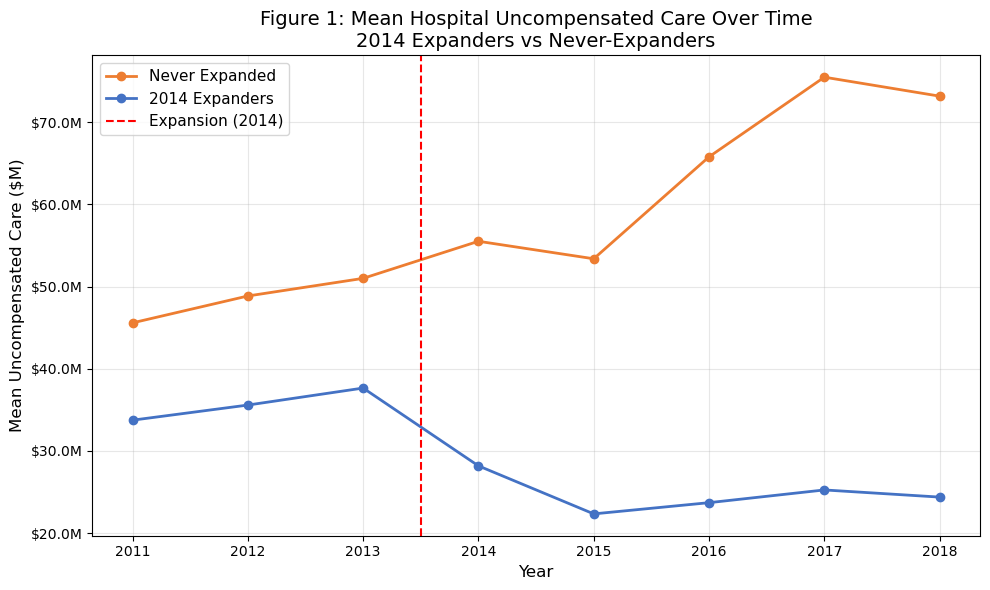

In [5]:
# Question 2: Plot mean uncompensated care over time separately for states that expanded Medicaid in 2014 versus states that never expanded. Drop all states that expanded after 2014. Does the graph suggest a potential treatment effect?
# Filter to 2014 expanders and never-expanders only
q2_dat = hcris[
    (hcris['expand_year'] == 2014) | (hcris['expand_ever'] == False)
].copy()

# Calculate mean by year and expansion group
q2_plot = (
    q2_dat
    .groupby(['year', 'expand_ever'], as_index=False)
    .agg(mean_uc=('uncomp_care_m', 'mean'))
)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

for expanded, grp in q2_plot.groupby('expand_ever'):
    label = '2014 Expanders' if expanded else 'Never Expanded'
    color = '#4472C4' if expanded else '#ED7D31'
    ax.plot(grp['year'], grp['mean_uc'], marker='o', label=label, color=color, linewidth=2)

ax.axvline(x=2013.5, color='red', linestyle='--', linewidth=1.5, label='Expansion (2014)')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Mean Uncompensated Care ($M)', fontsize=12)
ax.set_title('Figure 1: Mean Hospital Uncompensated Care Over Time\n2014 Expanders vs Never-Expanders', fontsize=14)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.1fM'))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../../../data/output/figure1_uc_trends.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
# Question 3: Using 2012 and 2015 as your pre and post periods, present a 2x2 DD table of mean uncompensated care for expansion versus non-expansion states.
# Filter to 2014 expanders and never-expanders, using 2012 and 2015
q3_dat = hcris[
    ((hcris['expand_year'] == 2014) | (hcris['expand_ever'] == False)) &
    (hcris['year'].isin([2012, 2015]))
].copy()

q3_dat['period'] = q3_dat['year'].map({2012: 'Pre (2012)', 2015: 'Post (2015)'})
q3_dat['group'] = q3_dat['expand_ever'].map({True: 'Expanded (2014)', False: 'Never Expanded'})

# Calculate means
q3_means = (
    q3_dat
    .groupby(['group', 'period'], as_index=False)
    .agg(mean_uc=('uncomp_care_m', 'mean'))
    .pivot(index='group', columns='period', values='mean_uc')
    .reset_index()
)

# Add difference column
q3_means['Difference (Post - Pre)'] = q3_means['Post (2015)'] - q3_means['Pre (2012)']

# Add DD row
dd_val = (
    q3_means.loc[q3_means['group'] == 'Expanded (2014)', 'Difference (Post - Pre)'].values[0] -
    q3_means.loc[q3_means['group'] == 'Never Expanded', 'Difference (Post - Pre)'].values[0]
)
dd_row = pd.DataFrame([{
    'group': 'DD Estimate',
    'Pre (2012)': None,
    'Post (2015)': None,
    'Difference (Post - Pre)': dd_val
}])
q3_table = pd.concat([q3_means, dd_row], ignore_index=True)
q3_table = q3_table.rename(columns={'group': 'Group'})

# Style the table
(q3_table.style
    .format({
        'Pre (2012)': lambda x: f'${x:.2f}M' if pd.notna(x) else '',
        'Post (2015)': lambda x: f'${x:.2f}M' if pd.notna(x) else '',
        'Difference (Post - Pre)': lambda x: f'${x:.2f}M' if pd.notna(x) else ''
    })
    .set_caption('Table 2: 2x2 Difference-in-Differences Table of Mean Uncompensated Care')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold')]},
        {'selector': 'th', 'props': [('background-color', '#4472C4'), ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'tr:last-child', 'props': [('font-weight', 'bold'), ('background-color', '#D9E1F2')]},
    ])
    .hide(axis='index')
)

Group,Post (2015),Pre (2012),Difference (Post - Pre)
Expanded (2014),$22.35M,$35.58M,$-13.24M
Never Expanded,$53.38M,$48.85M,$4.53M
DD Estimate,,,$-17.76M


### Question 4: Briefly discuss what policies or events might explain the trends you observe. Why might we expect Medicaid expansion to affect uncompensated care?
#### Uncompensated care declined for both expanding and non-expanding states over the 2011–2018 period, but the decline was notably sharper for states that expanded Medicaid in 2014, which suggests there are potential treatment effect. This pattern is consistent with the economic logic of Medicaid expansion which is that prior to expansion, low-income uninsured patients who received hospital care generated uncompensated costs that hospitals could not recover. However, by extending Medicaid coverage to adults up to 138% of the federal poverty level, expansion converted many previously uninsured patients into Medicaid-covered patients. This directly reduced the volume of care hospitals had to absorb without payment. The downward trend observed even in non-expanding states is likely explained by the ACA's individual mandate, also implemented in 2014 as well as the broader economic recovery following the 2008 recession, both of which reduced uninsured rates nationally regardless of expansion status.

#### Part 2: Estimate ATEs

In [8]:
# Question 5: Estimate the effect of Medicaid expansion on hospital uncompensated care using a standard DD regression estimator, focusing only on states that expanded in 2014 versus those that never expanded.
# Filter to 2014 expanders and never-expanders only
reg_dat = hcris[
    (hcris['expand_year'] == 2014) | (hcris['expand_ever'] == False)
].copy()

reg_dat['post'] = (reg_dat['year'] >= 2014).astype(int)
reg_dat['treat'] = (reg_dat['expand_ever'].astype(bool) & reg_dat['post'].astype(bool)).astype(int)
reg_dat['expand_ever'] = reg_dat['expand_ever'].astype(int)

# Standard DD regression
dd_reg = smf.ols(
    'uncomp_care_m ~ post + expand_ever + treat',
    data=reg_dat
).fit()

# Build results table
dd_results = pd.DataFrame({
    'Coefficient': dd_reg.params,
    'Std Error': dd_reg.bse,
    't-stat': dd_reg.tvalues,
    'p-value': dd_reg.pvalues,
    '95% CI Lower': dd_reg.conf_int()[0],
    '95% CI Upper': dd_reg.conf_int()[1]
}).reset_index().rename(columns={'index': 'Variable'})

# Add observations and R-squared as bottom rows
stats_rows = pd.DataFrame([
    {'Variable': 'Observations', 'Coefficient': int(dd_reg.nobs),
     'Std Error': None, 't-stat': None, 'p-value': None,
     '95% CI Lower': None, '95% CI Upper': None},
    {'Variable': 'R-squared', 'Coefficient': round(dd_reg.rsquared, 4),
     'Std Error': None, 't-stat': None, 'p-value': None,
     '95% CI Lower': None, '95% CI Upper': None}
])
dd_results = pd.concat([dd_results, stats_rows], ignore_index=True)

# Style the table
(dd_results.style
    .format({
        'Coefficient': lambda x: f'{int(x):,}' if isinstance(x, float) and x > 100
                        else (f'{x:.4f}' if pd.notna(x) else ''),
        'Std Error': lambda x: f'{x:.4f}' if pd.notna(x) else '',
        't-stat': lambda x: f'{x:.3f}' if pd.notna(x) else '',
        'p-value': lambda x: f'{x:.4f}' if pd.notna(x) else '',
        '95% CI Lower': lambda x: f'{x:.4f}' if pd.notna(x) else '',
        '95% CI Upper': lambda x: f'{x:.4f}' if pd.notna(x) else ''
    })
    .set_caption('Table 3: Standard DD Regression — 2014 Expanders vs Never-Expanders')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold')]},
        {'selector': 'th', 'props': [('background-color', '#4472C4'), ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'tr:last-child', 'props': [('background-color', '#D9E1F2'), ('font-weight', 'bold')]},
        {'selector': 'tr:nth-last-child(2)', 'props': [('background-color', '#D9E1F2'), ('font-weight', 'bold')]},
    ])
    .apply(lambda x: ['background-color: #fff2cc' if pd.notna(x['p-value']) and x['p-value'] < 0.05
                       else '' for _ in x], axis=1)
    .hide(axis='index')
)

Variable,Coefficient,Std Error,t-stat,p-value,95% CI Lower,95% CI Upper
Intercept,49.0545,2.2737,21.575,0.0000,44.5978,53.5113
post,14.8221,2.8245,5.248,0.0000,9.2858,20.3585
expand_ever,-13.1194,2.8654,-4.579,0.0000,-18.7359,-7.5028
treat,-25.9697,3.5668,-7.281,0.0000,-32.9611,-18.9782
Observations,"14,295",,,,,
R-squared,0.0246,,,,,


In [9]:
# Question 6: Include hospital and year fixed effects in your estimates using the fixest package. Cluster your standard errors at the state level. How do your results compare to those in question 5?
# Prepare panel data - drop missing uncomp_care_m
reg_dat_fe = reg_dat.dropna(subset=['uncomp_care_m']).copy()
reg_dat_fe['provider_number'] = reg_dat_fe['provider_number'].astype(str)

# Set MultiIndex for PanelOLS
panel = reg_dat_fe.set_index(['provider_number', 'year'])

y = panel['uncomp_care_m']
X = panel[['treat']]

# TWFE with hospital and year fixed effects, clustered SEs at state level
twfe = PanelOLS(
    y, X,
    entity_effects=True,
    time_effects=True
)
twfe_res = twfe.fit(
    cov_type='clustered',
    cluster_entity=False,
    cluster_time=False,
    clusters=reg_dat_fe.set_index(['provider_number', 'year'])['state']
)

# Display results
twfe_table = pd.DataFrame({
    'Coefficient': twfe_res.params,
    'Std Error': twfe_res.std_errors,
    't-stat': twfe_res.tstats,
    'p-value': twfe_res.pvalues,
    '95% CI Lower': twfe_res.conf_int()['lower'],
    '95% CI Upper': twfe_res.conf_int()['upper']
}).reset_index().rename(columns={'index': 'Variable'})

print(f'Observations: {int(twfe_res.nobs):,}  |  R-squared (within): {twfe_res.rsquared_within:.4f}')

(twfe_table.style
    .format({
        'Coefficient': '{:.4f}',
        'Std Error': '{:.4f}',
        't-stat': '{:.3f}',
        'p-value': '{:.4f}',
        '95% CI Lower': '{:.4f}',
        '95% CI Upper': '{:.4f}'
    })
    .set_caption('Table 4: TWFE DD — Hospital & Year Fixed Effects, State-Clustered SEs')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold')]},
        {'selector': 'th', 'props': [('background-color', '#4472C4'), ('color', 'white'), ('font-weight', 'bold')]},
    ])
    .apply(lambda x: ['background-color: #D9E1F2' if x['p-value'] < 0.05 else '' for _ in x], axis=1)
    .hide(axis='index')
)

Observations: 14,295  |  R-squared (within): -0.0189


Variable,Coefficient,Std Error,t-stat,p-value,95% CI Lower,95% CI Upper
treat,-29.5948,6.2303,-4.750,0.0000,-41.8073,-17.3823


In [11]:
# Question 7: Repeat the analysis in question 6 but include all states (even those that expanded after 2014). Are your results different? If so, why?
# Use full dataset (all expansion years + never expanders)
reg_dat_all = hcris[~hcris['expand_ever'].isna()].copy()
reg_dat_all['post'] = (reg_dat_all['year'] >= 2014).astype(int)
reg_dat_all['expand_ever'] = reg_dat_all['expand_ever'].astype(bool)
reg_dat_all['treat'] = (
    reg_dat_all['expand_ever'] &
    (reg_dat_all['year'] >= reg_dat_all['expand_year'].fillna(9999))
).astype(int)
reg_dat_all = reg_dat_all.dropna(subset=['uncomp_care_m']).copy()
reg_dat_all['provider_number'] = reg_dat_all['provider_number'].astype(str)

# Set MultiIndex
panel_all = reg_dat_all.set_index(['provider_number', 'year'])
y_all = panel_all['uncomp_care_m']
X_all = panel_all[['treat']]

# TWFE
twfe_all = PanelOLS(y_all, X_all, entity_effects=True, time_effects=True)
twfe_all_res = twfe_all.fit(
    cov_type='clustered',
    cluster_entity=False,
    cluster_time=False,
    clusters=reg_dat_all.set_index(['provider_number', 'year'])['state']
)

# Display results
twfe_all_table = pd.DataFrame({
    'Coefficient': twfe_all_res.params,
    'Std Error': twfe_all_res.std_errors,
    't-stat': twfe_all_res.tstats,
    'p-value': twfe_all_res.pvalues,
    '95% CI Lower': twfe_all_res.conf_int()['lower'],
    '95% CI Upper': twfe_all_res.conf_int()['upper']
}).reset_index().rename(columns={'index': 'Variable'})

print(f'Observations: {int(twfe_all_res.nobs):,}  |  R-squared (within): {twfe_all_res.rsquared_within:.4f}')

(twfe_all_table.style
    .format({
        'Coefficient': '{:.4f}',
        'Std Error': '{:.4f}',
        't-stat': '{:.3f}',
        'p-value': '{:.4f}',
        '95% CI Lower': '{:.4f}',
        '95% CI Upper': '{:.4f}'
    })
    .set_caption('Table 5: TWFE DD — All States, Hospital & Year Fixed Effects, State-Clustered SEs')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold')]},
        {'selector': 'th', 'props': [('background-color', '#4472C4'), ('color', 'white'), ('font-weight', 'bold')]},
    ])
    .apply(lambda x: ['background-color: #D9E1F2' if x['p-value'] < 0.05 else '' for _ in x], axis=1)
    .hide(axis='index')
)

Observations: 19,118  |  R-squared (within): -0.0002


Variable,Coefficient,Std Error,t-stat,p-value,95% CI Lower,95% CI Upper
treat,-22.9639,4.9887,-4.603,0.0000,-32.7423,-13.1854


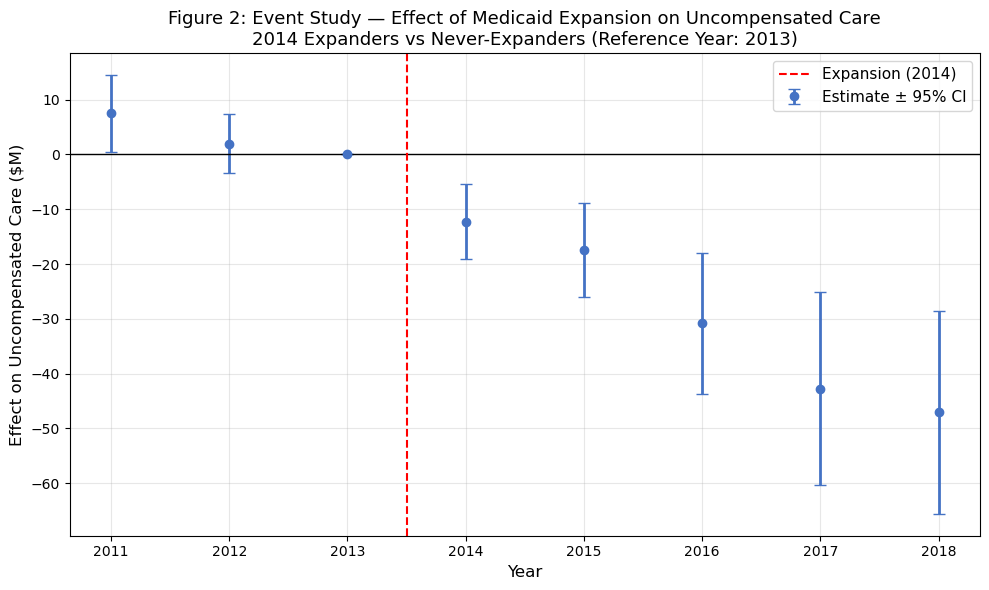

In [15]:
# Question 8: Provide an “event study” graph showing the effects of Medicaid expansion in each year. Use the specification that includes hospital and year fixed effects, limited to states that expanded in 2014 or never expanded (with 2013 as the reference year).
es_dat = hcris[
    (hcris['expand_year'] == 2014) | (hcris['expand_ever'] == False)
].dropna(subset=['uncomp_care_m']).copy()

es_dat['expand_ever'] = es_dat['expand_ever'].astype(int)
es_dat['provider_number'] = es_dat['provider_number'].astype(str)

# Run event study regression - year dummies interacted with expand_ever
# 2013 is the reference year (omitted)
years = [2011, 2012, 2014, 2015, 2016, 2017, 2018]
for yr in years:
    es_dat[f'treat_{yr}'] = ((es_dat['year'] == yr) & (es_dat['expand_ever'] == 1)).astype(int)

# Build formula with explicit year-treatment interactions
interact_terms = ' + '.join([f'treat_{yr}' for yr in years])
formula = f'uncomp_care_m ~ {interact_terms} + C(provider_number) + C(year)'

es_reg = smf.ols(formula, data=es_dat).fit(
    cov_type='cluster',
    cov_kwds={'groups': es_dat['state']}
)

# Extract coefficients
event_years = [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018]
coefs = []
ses = []

for yr in event_years:
    if yr == 2013:
        coefs.append(0.0)
        ses.append(0.0)
    else:
        coefs.append(es_reg.params[f'treat_{yr}'])
        ses.append(es_reg.bse[f'treat_{yr}'])

es_plot = pd.DataFrame({
    'year': event_years,
    'coef': coefs,
    'se': ses
})
es_plot['ci_lower'] = es_plot['coef'] - 1.96 * es_plot['se']
es_plot['ci_upper'] = es_plot['coef'] + 1.96 * es_plot['se']

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(es_plot['year'], es_plot['coef'],
            yerr=1.96 * es_plot['se'],
            fmt='o', color='#4472C4', ecolor='#4472C4',
            capsize=4, linewidth=2, markersize=6, label='Estimate ± 95% CI')
ax.axhline(0, color='black', linewidth=1)
ax.axvline(2013.5, color='red', linestyle='--', linewidth=1.5, label='Expansion (2014)')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Effect on Uncompensated Care ($M)', fontsize=12)
ax.set_title('Figure 2: Event Study — Effect of Medicaid Expansion on Uncompensated Care\n2014 Expanders vs Never-Expanders (Reference Year: 2013)', fontsize=13)
ax.set_xticks(event_years)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../../../data/output/figure2_event_study_2014.png', dpi=300, bbox_inches='tight')
plt.show()

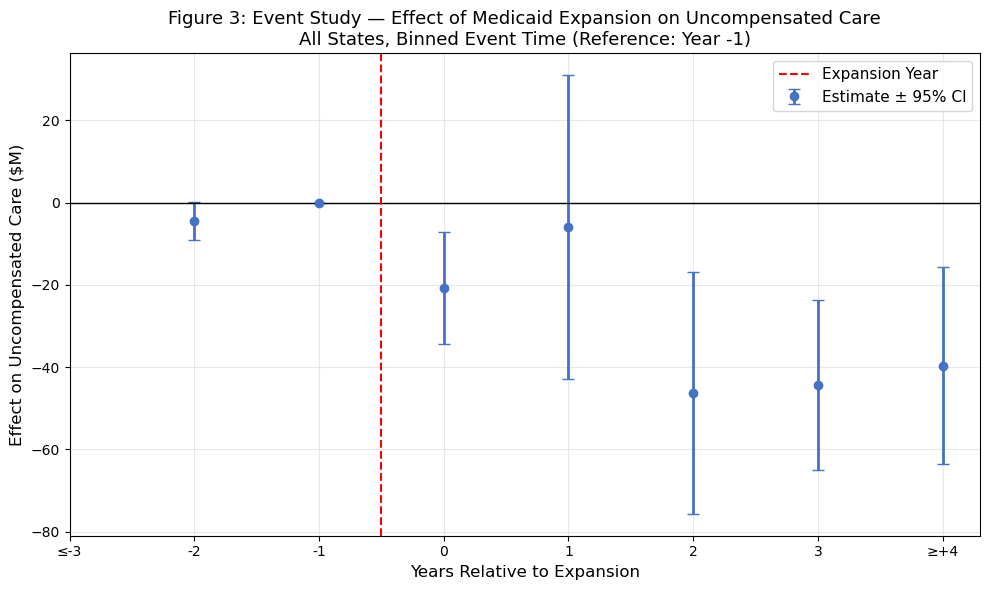

In [14]:
# Question 9: Repeat part 8 but include all states that expanded after 2014. You will need to construct an “event time” variable and bin end points as discussed in class.
# Use all states
es_all = hcris[hcris['expand_ever'].notna()].dropna(subset=['uncomp_care_m']).copy()
es_all['expand_ever'] = es_all['expand_ever'].astype(bool)

# Build event time variable
es_all['time_to_treat'] = np.where(
    es_all['expand_ever'],
    es_all['year'] - es_all['expand_year'],
    0
).astype(float)

# Bin endpoints: cap at -3 on the low end and +4 on the high end
es_all['time_to_treat'] = es_all['time_to_treat'].clip(lower=-3, upper=4)
es_all['time_to_treat'] = es_all['time_to_treat'].astype(int)

# Never-expanders get time_to_treat = 0 (already set above)
# Reference period is -1 (year before expansion)
es_all = es_all[es_all['time_to_treat'] != -1].copy()  # drop reference year

es_all['provider_number'] = es_all['provider_number'].astype(str)

# Run regression
es_all_reg = smf.ols(
    'uncomp_care_m ~ C(time_to_treat) + C(provider_number) + C(year)',
    data=es_all
).fit(cov_type='cluster', cov_kwds={'groups': es_all['state']})

# Extract coefficients for event time dummies
time_periods = [-3, -2, 0, 1, 2, 3, 4]
coef_all = {}
se_all = {}

for t in time_periods:
    key = [k for k in es_all_reg.params.index if f'C(time_to_treat)[T.{t}]' in k]
    if key:
        coef_all[t] = es_all_reg.params[key[0]]
        se_all[t] = es_all_reg.bse[key[0]]
    else:
        coef_all[t] = np.nan
        se_all[t] = np.nan

# Add reference year (-1) as zero
coef_all[-1] = 0.0
se_all[-1] = 0.0

all_periods = sorted(coef_all.keys())
es_all_plot = pd.DataFrame({
    'time': all_periods,
    'coef': [coef_all[t] for t in all_periods],
    'se': [se_all[t] for t in all_periods]
})
es_all_plot['ci_lower'] = es_all_plot['coef'] - 1.96 * es_all_plot['se']
es_all_plot['ci_upper'] = es_all_plot['coef'] + 1.96 * es_all_plot['se']

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(es_all_plot['time'], es_all_plot['coef'],
            yerr=1.96 * es_all_plot['se'],
            fmt='o', color='#4472C4', ecolor='#4472C4',
            capsize=4, linewidth=2, markersize=6, label='Estimate ± 95% CI')
ax.axhline(0, color='black', linewidth=1)
ax.axvline(-0.5, color='red', linestyle='--', linewidth=1.5, label='Expansion Year')
ax.set_xlabel('Years Relative to Expansion', fontsize=12)
ax.set_ylabel('Effect on Uncompensated Care ($M)', fontsize=12)
ax.set_title('Figure 3: Event Study — Effect of Medicaid Expansion on Uncompensated Care\nAll States, Binned Event Time (Reference: Year -1)', fontsize=13)
ax.set_xticks(all_periods)
ax.set_xticklabels([f'≤-3' if t == -3 else f'≥+4' if t == 4 else str(t) for t in all_periods])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../../../data/output/figure3_event_study_all.png', dpi=300, bbox_inches='tight')
plt.show()

##### Question 10: Summarize your findings from questions 5-9. What is the effect of Medicaid expansion on hospital uncompensated care? Do the event study graphs suggest any concerns about the parallel trends assumption? Briefly discuss one limitation of the standard TWFE estimator in the context of staggered Medicaid expansion.

The DD estimates consistently show that Medicaid expansion significantly reduced hospital uncompensated care. The standard DD estimate in question 5 shows a reduction of about $26M, while the TWFE estimate in question 6 grows slightly to $29.6M once hospital and year fixed effects are added. When all states are included in question, the estimate falls to $23M. In addition to this, the event study in question 8 supports the idea that expanding and non-expanding states were on similar trajectories before 2014 since the 2012 and 2013 pre-expansion coefficients are close to zero and statistically insignificant. In regard to a potential limitation with the TWFE is that the standard estimator can be problematic under staggered treatment timing because it uses already-treated states as controls for newly treated ones. Meaning the results can be a bit misleading.